Crack half-length a = 0.005 m, sigma_yy = 100 MPa
K_I  (COD-fit)  = 3.06236 MPa*sqrt(m)   meta: r=[1.667e-05,4.674e-05], n_fit=19
K_I  (tip-slope)= 17.7727 MPa*sqrt(m)
K_I  (analytic) = 12.5331 MPa*sqrt(m)


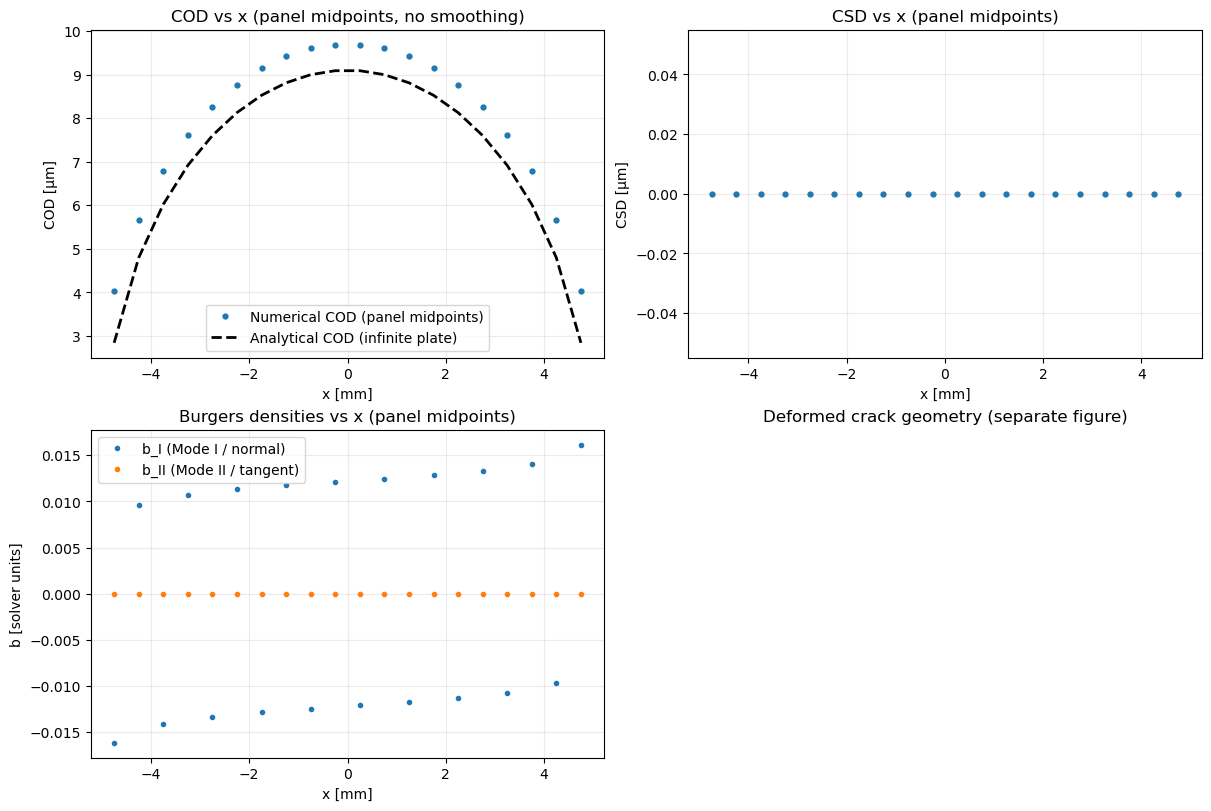

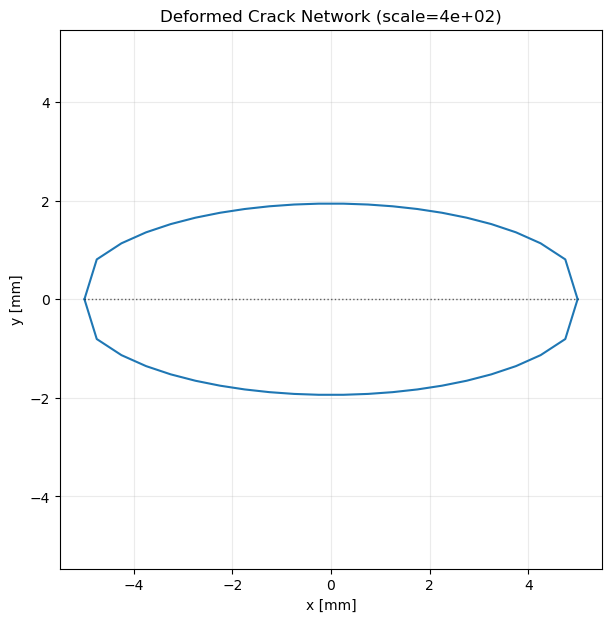

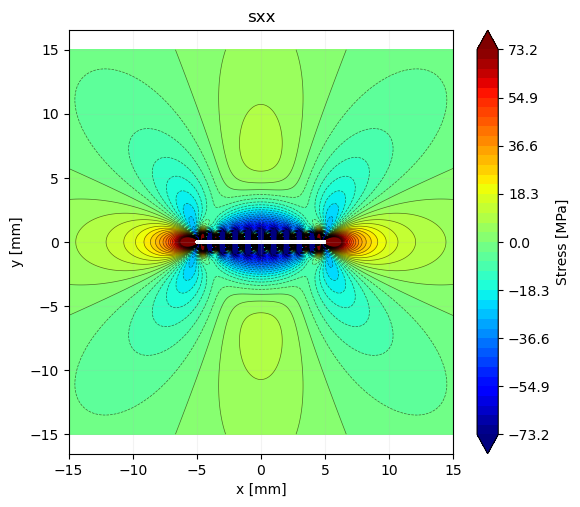

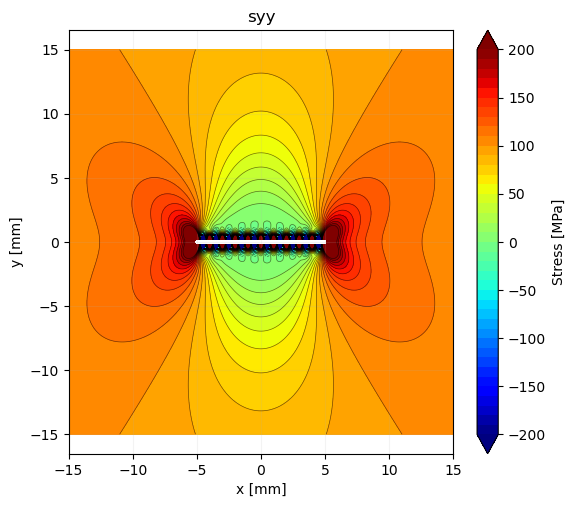

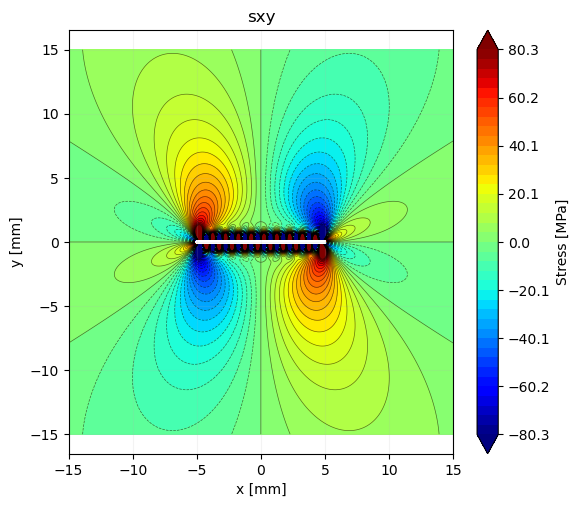

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\validation_single_crack


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# --- Ensure repo root on sys.path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils
utils.reload_all()
from utils import *

out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\validation_single_crack")
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Problem definition
# -------------------------
mat  = Material(E=200e9, nu=0.30, plane_stress=False)
appl = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0.0)  # Pa
sigma_yy = appl.sigma_yy

a = 5e-3  # m half-length (2a = 10 mm)

# Build a 2-vertex / 1-edge network (straight crack along x)
V = np.array([[0, -a, 0.0],
              [1, +a, 0.0]], dtype=float)
Econn = np.array([[0, 0, 1]], dtype=int)

net  = CrackNetworkV4.from_vertices_connectivity(V, Econn, Nv_max=2, validate=True)
calc = DCENetworkStaticV4(material=mat, network=net, applied=appl)

# -------------------------
# Solve
# -------------------------
ne_half = 10
sol = calc.solve(
    ne_half=ne_half,
    representation="panel",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    n_int=96,
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=None)

# -------------------------
# Midpoint reconstruction (NO smoothing)
# -------------------------
x_mid, COD_mid, CSD_mid, extra = res.reconstruct_cod_csd_panel_midpoints(
    edge_index=0,
    enforce_global_tip_zero=True,
)

bI  = np.asarray(extra["bI"], float)
bII = np.asarray(extra["bII"], float)

# Analytical COD (infinite plate, central crack)
Eprime = mat.E / (1.0 - mat.nu**2) if (not mat.plane_stress) else mat.E
COD_anal_mid = (4.0 * sigma_yy / Eprime) * np.sqrt(np.maximum(a*a - x_mid*x_mid, 0.0))

# -------------------------
# SIFs (use dense COD for fitting ONLY)
# -------------------------
# For SIF extraction you generally want a dense near-tip curve; plotting does not.
x_dense, COD_dense, CSD_dense = res.reconstruct_cod_csd_parametrized(
    edge_index=0, n_pts=6000, enforce_global_tip_zero=True
)

mu    = calc.material.mu
kappa = calc.material.kappa

KI_fit, KII_fit, meta = sif_from_cod_fit(
    x_dense, COD_dense, CSD_dense,
    a=a, mu=mu, kappa=kappa,
    tip="right", window="auto", two_term=True
)

KI_tip_r = estimate_K_from_jump_near_tip(x_dense, COD_dense, a, Eprime, side="right", frac_window=0.08)
KI_tip_l = estimate_K_from_jump_near_tip(x_dense, COD_dense, a, Eprime, side="left",  frac_window=0.08)
KI_tip   = np.nanmean([KI_tip_l, KI_tip_r])

KI_anal = sigma_yy * np.sqrt(np.pi * a)

print(f"Crack half-length a = {a:.6g} m, sigma_yy = {sigma_yy/1e6:.3g} MPa")
print(f"K_I  (COD-fit)  = {KI_fit/1e6:.6g} MPa*sqrt(m)   meta: r=[{meta['r_min']:.3e},{meta['r_max']:.3e}], n_fit={meta['n_fit']}")
print(f"K_I  (tip-slope)= {KI_tip/1e6:.6g} MPa*sqrt(m)")
print(f"K_I  (analytic) = {KI_anal/1e6:.6g} MPa*sqrt(m)")

# -------------------------
# Plots (midpoints for COD/CSD and b)
# -------------------------
fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

ax[0,0].plot(x_mid*1e3, COD_mid*1e6, "o", ms=3.5, label="Numerical COD (panel midpoints)")
ax[0,0].plot(x_mid*1e3, COD_anal_mid*1e6, "k--", lw=2.0, label="Analytical COD (infinite plate)")
ax[0,0].set_title("COD vs x (panel midpoints, no smoothing)")
ax[0,0].set_xlabel("x [mm]")
ax[0,0].set_ylabel("COD [µm]")
ax[0,0].grid(True, alpha=0.25)
ax[0,0].legend()

ax[0,1].plot(x_mid*1e3, CSD_mid*1e6, "o", ms=3.5)
ax[0,1].set_title("CSD vs x (panel midpoints)")
ax[0,1].set_xlabel("x [mm]")
ax[0,1].set_ylabel("CSD [µm]")
ax[0,1].grid(True, alpha=0.25)

ax[1,0].plot(x_mid*1e3, bI,  "o", ms=3.0, label="b_I (Mode I / normal)")
ax[1,0].plot(x_mid*1e3, bII, "o", ms=3.0, label="b_II (Mode II / tangent)")
ax[1,0].set_title("Burgers densities vs x (panel midpoints)")
ax[1,0].set_xlabel("x [mm]")
ax[1,0].set_ylabel("b [solver units]")
ax[1,0].grid(True, alpha=0.25)
ax[1,0].legend()

ax[1,1].axis("off")
ax[1,1].set_title("Deformed crack geometry (separate figure)")

plt.show()

# -------------------------
# Deformed crack geometry (midpoints default in patched plotter)
# -------------------------
plotter.plot_deformed_network(
    scale=4e2,
    show_faces=True,
    units="mm",
    # use_panel_midpoints is default True in patched plotter
    # cod_smooth_window=0, csd_smooth_window=0  # optional, not needed
)
plt.show()


# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)

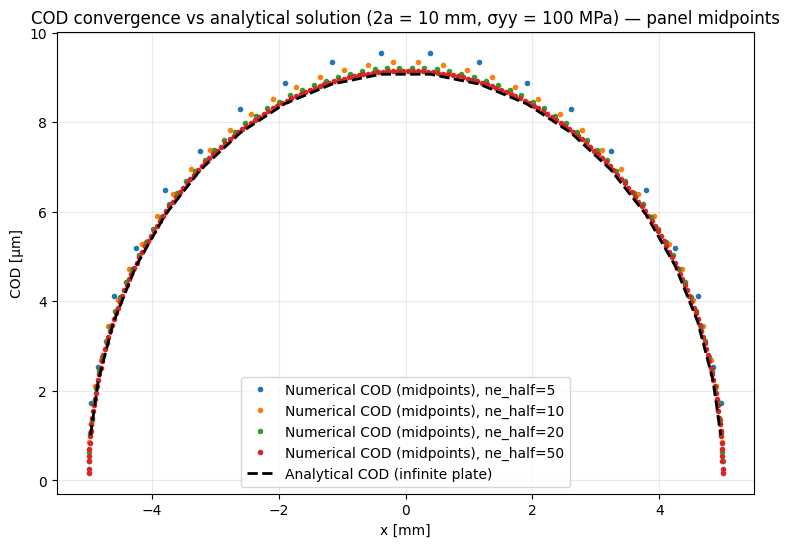

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# --- Ensure repo root on sys.path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)


import utils
utils.reload_all()
from utils import *
# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\validation_single_crack")
out_dir.mkdir(parents=True, exist_ok=True)

mat  = Material(E=200e9, nu=0.30, plane_stress=False)
appl = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0.0)  # Pa

sigma_yy = appl.sigma_yy
Eprime   = mat.E / (1.0 - mat.nu**2) if (not mat.plane_stress) else mat.E

# Convergence sets
ne_list = [5, 10, 20, 50]

# Helper: build single straight crack network
def build_single_crack_calc(a):
    V = np.array([[0, -a, 0.0],
                  [1, +a, 0.0]], dtype=float)
    Econn = np.array([[0, 0, 1]], dtype=int)
    net = CrackNetworkV4.from_vertices_connectivity(V, Econn, Nv_max=2, validate=True)
    calc = DCENetworkStaticV4(material=mat, network=net, applied=appl)
    return calc

# Helper: solve and return midpoint COD for plotting + KI from TIP-SLOPE ONLY
def solve_codmid_and_KI_tip(a, ne_half, n_dense=6000, frac_window=0.08):
    calc = build_single_crack_calc(a)

    sol = calc.solve(
        ne_half=ne_half,
        representation="cheb_quad",
        node_distribution="tip_dense",
        solver_option="parametrized_crack",
        parametrization="polyline",
        nq_col=3,
        nq_stress=6,
        n_int=96,
    )

    res = processor.DCEResultsNetworkV4(calc, sol)

    # --- Midpoint COD for plotting (no oscillations)
    x_mid, COD_mid, CSD_mid, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=0,
        enforce_global_tip_zero=True
    )

    # --- Dense COD for tip-slope KI extraction (stable near-tip sampling)
    x, COD, CSD = res.reconstruct_cod_csd_parametrized(
        edge_index=0, n_pts=n_dense, enforce_global_tip_zero=True
    )

    KI_r = estimate_K_from_jump_near_tip(x, COD, a, Eprime, side="right", frac_window=frac_window)
    KI_l = estimate_K_from_jump_near_tip(x, COD, a, Eprime, side="left",  frac_window=frac_window)
    KI_tip = np.nanmean([KI_l, KI_r])

    return np.asarray(x_mid), np.asarray(COD_mid), float(KI_tip)

# Analytical COD for an infinite plate, central crack length 2a:
# COD(x) = (4 σ / E') * sqrt(a^2 - x^2)
def cod_analytical(x, a):
    x = np.asarray(x, float)
    return (4.0 * sigma_yy / Eprime) * np.sqrt(np.maximum(a*a - x*x, 0.0))

# Analytical KI
def KI_analytical(a):
    return sigma_yy * np.sqrt(np.pi * a)

# ============================================================================
# (1) Plot analytical COD vs numerical COD (MIDPOINTS) for ne_half = 5,10,20,50
# ============================================================================
a_cod = 5e-3  # m (2a = 10 mm)

plt.figure(figsize=(9, 6))
x_ref = None

for ne in ne_list:
    x_mid, COD_mid, KI_tip = solve_codmid_and_KI_tip(a_cod, ne, n_dense=6000, frac_window=0.08)
    if x_ref is None:
        x_ref = x_mid
    plt.plot(x_mid*1e3, COD_mid*1e6, "o", ms=3.0, label=f"Numerical COD (midpoints), ne_half={ne}")

COD_an = cod_analytical(x_ref, a_cod)
plt.plot(x_ref*1e3, COD_an*1e6, "k--", linewidth=2.0, label="Analytical COD (infinite plate)")

plt.title("COD convergence vs analytical solution (2a = 10 mm, σyy = 100 MPa) — panel midpoints")
plt.xlabel("x [mm]")
plt.ylabel("COD [µm]")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

# ============================================================================
# (2) Plot analytical KI vs crack length 2a (1–20 mm)
#     and numerical KI (TIP-SLOPE) for ne_half = 5,10,20,50
# ============================================================================
a_vals = np.linspace(0.5e-3, 10e-3, 16)   # half-lengths (m) => 2a in [1, 20] mm
two_a_mm = 2.0 * a_vals * 1e3

# Analytical
KI_an = np.array([KI_analytical(a) for a in a_vals], float)

# Numerical (tip-slope) for each ne_half
markers = {5: "o", 10: "s", 20: "D", 50: "^"}
KI_num = {ne: [] for ne in ne_list}

for ne in ne_list:
    for a in a_vals:
        _, _, KI_tip = solve_codmid_and_KI_tip(
            a, ne_half=ne, n_dense=6000, frac_window=0.08
        )
        KI_num[ne].append(KI_tip)
    KI_num[ne] = np.asarray(KI_num[ne], float)

# --- Plot
plt.figure(figsize=(9, 6))

# Analytical (solid line)
plt.plot(two_a_mm, KI_an/1e6, "-", linewidth=2.5,
         label=r"Analytical $K_I=\sigma\sqrt{\pi a}$")

# Numerical (symbols)
for ne in ne_list:
    plt.plot(
        two_a_mm,
        KI_num[ne]/1e6,
        markers[ne],
        linestyle="None",
        markersize=6,
        label=f"Numerical (tip-slope), ne_half={ne}"
    )

plt.title(r"$K_I$ vs crack length (infinite-plate reference), $\sigma_{yy}=100$ MPa")
plt.xlabel("Crack length 2a [mm]")
plt.ylabel(r"$K_I$ [MPa$\sqrt{\mathrm{m}}$]")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

# ============================================================================
# (3) Error in KI at 2a = 10 mm (a = 5 mm) for tip-slope estimator vs ne_half
# ============================================================================
a_err = 5e-3
KI_ref = KI_analytical(a_err)

errs_tip = []

for ne in ne_list:
    _, _, KI_tip = solve_codmid_and_KI_tip(a_err, ne, n_dense=6000, frac_window=0.08)
    errs_tip.append((KI_tip - KI_ref)/KI_ref * 100.0)

errs_tip = np.asarray(errs_tip, float)

plt.figure(figsize=(9, 5))
plt.plot(ne_list, errs_tip, "o-", label="Tip-slope estimator error")
plt.axhline(0.0, linestyle="--")
plt.title(r"Error in $K_I$ at 2a = 10 mm vs ne_half (σyy = 100 MPa) — tip-slope estimator")
plt.xlabel("ne_half")
plt.ylabel("Relative error in $K_I$ [%]")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

# Print numeric table for reference
print("a = 5 mm (2a=10 mm), σyy=100 MPa")
print(f"Analytical KI = {KI_ref/1e6:.6g} MPa*sqrt(m)")
for ne, e2 in zip(ne_list, errs_tip):
    print(f"ne_half={ne:>3d} : error(tip-slope)={e2:>9.4f}%")


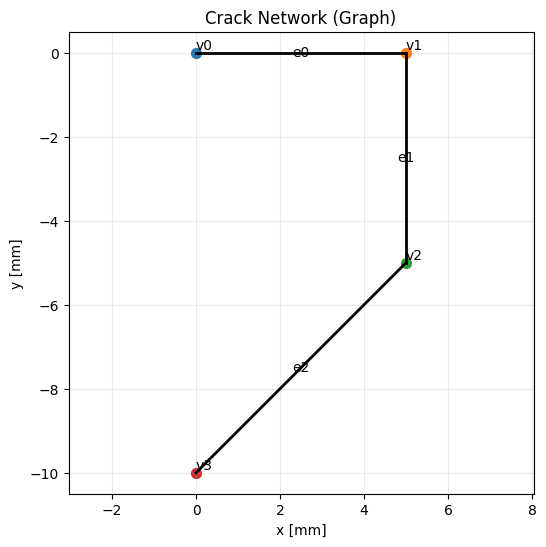

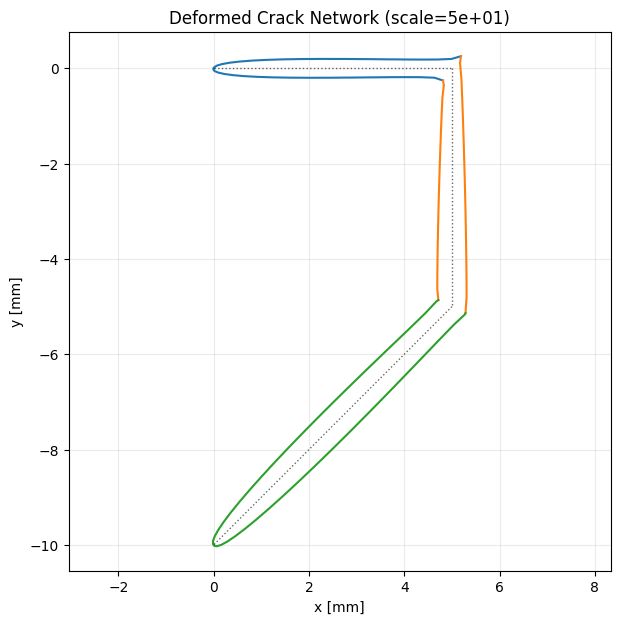

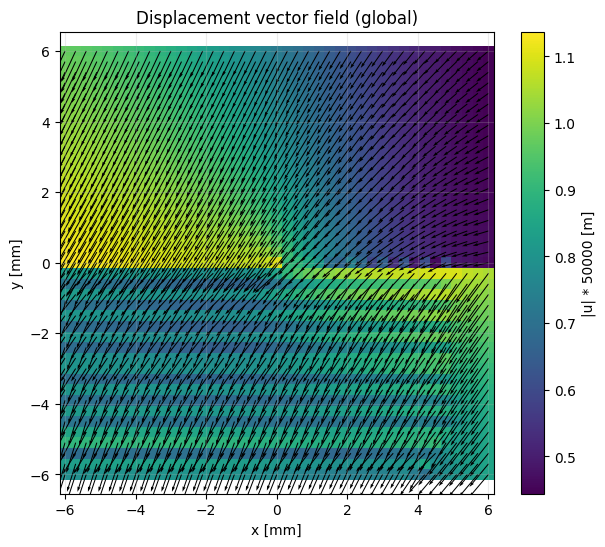

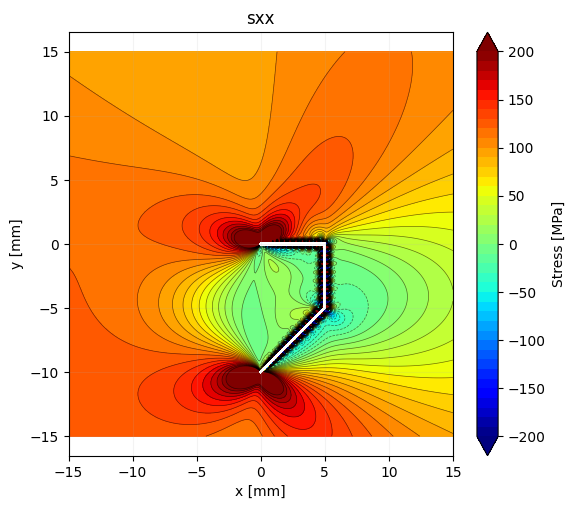

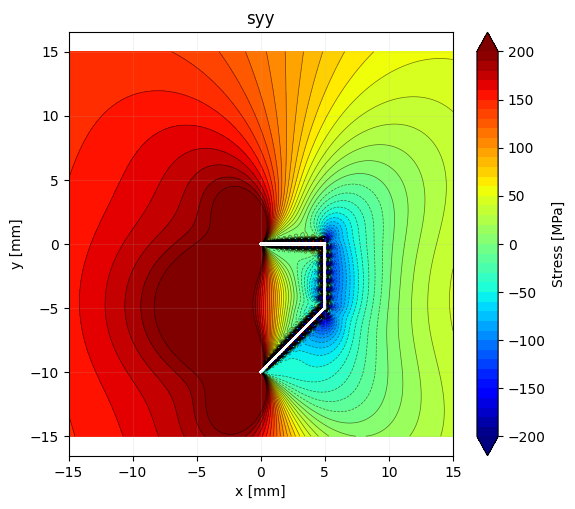

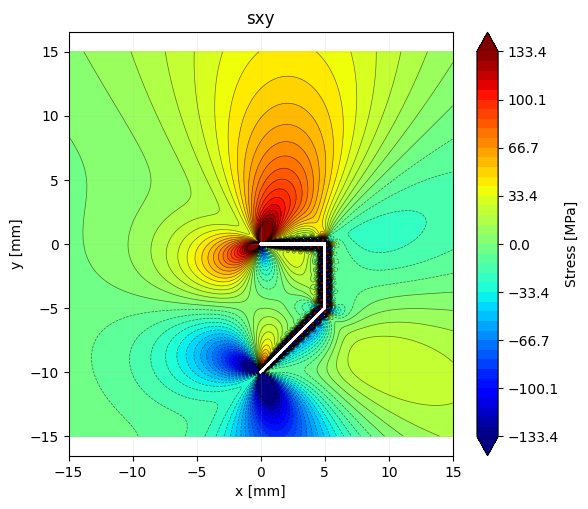

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# --- Ensure repo root on sys.path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils
utils.reload_all()
from utils import *
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 junction
    [1,   5.0*mm,  0*mm], # v1 upper-right
    [2,   5.0*mm, -5.0*mm], # v2 lower-right
    [3,  0*mm,  -10.0*mm], # v3 extended lower-right
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
    [1, 2],
    [2, 3]
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

# -------------------------
# Solve
# -------------------------
sol = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,   # OK to keep; ignored by the delegated single-crack solve
    n_int=96,
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=5e1, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)


CRACK NETWORK STATISTICS

Vertices:
  Total: 14
  Tips (degree 1): 14
  Kinks (degree 2): 0
  Junctions (degree 3+): 0

Edges:
  Total: 7
  Length range: [17.36, 19.71] mm
  Mean length: 18.99 mm
  Std dev: 0.94 mm

Degree distribution:
  Degree 1: 14 vertices

Connected components (paths): 7
  Path 1: 2 vertices, 1 edges
  Path 2: 2 vertices, 1 edges
  Path 3: 2 vertices, 1 edges
  Path 4: 2 vertices, 1 edges
  Path 5: 2 vertices, 1 edges
  Path 6: 2 vertices, 1 edges
  Path 7: 2 vertices, 1 edges


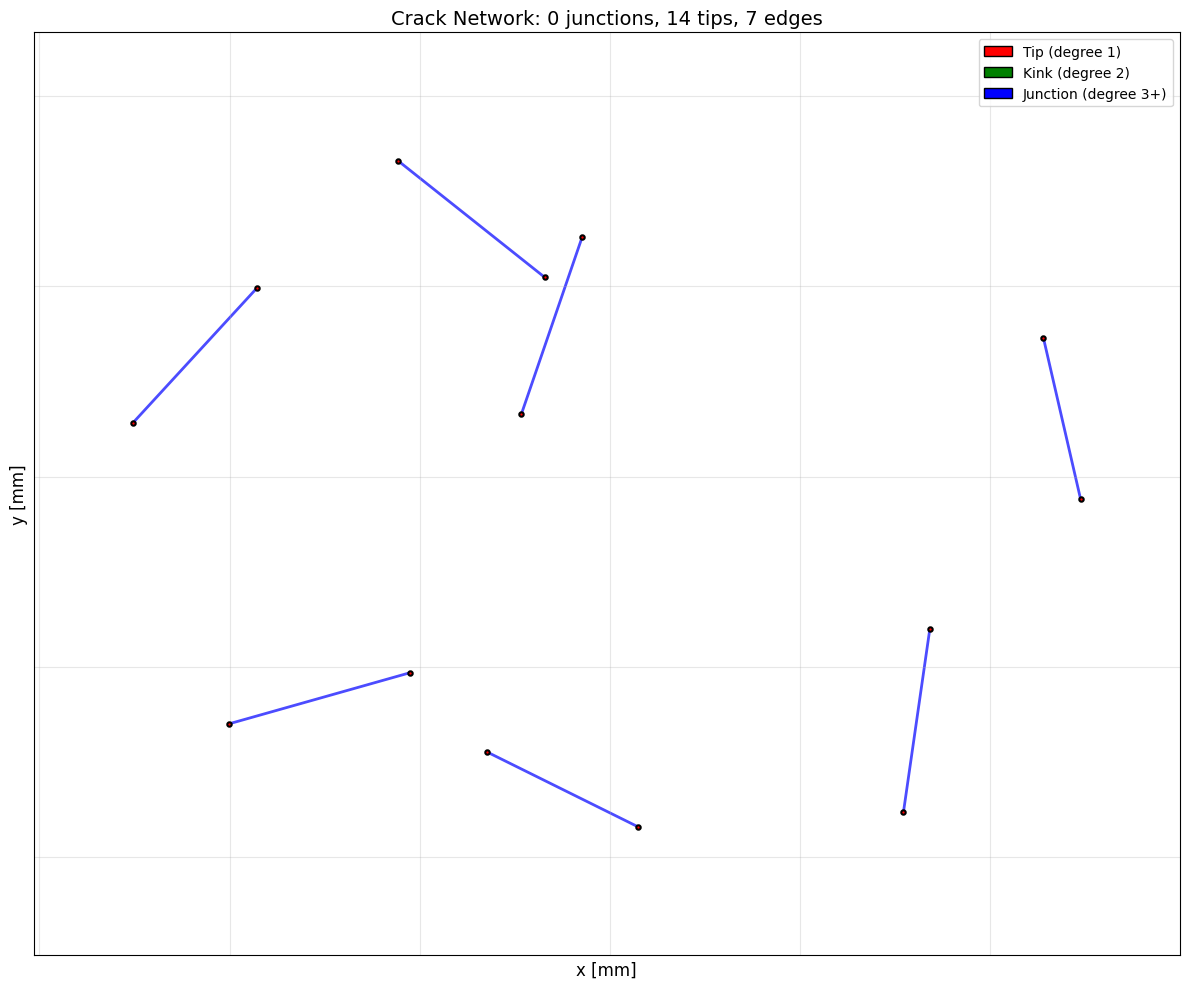


EXPORTED ARRAYS

vertices =
[[ 0.00000000e+00 -2.91403040e-03  4.51755390e-02]
 [ 1.00000000e+00 -9.31028165e-03  2.65440450e-02]
 [ 2.00000000e+00  4.56119288e-02  3.45730241e-02]
 [ 3.00000000e+00  4.95125415e-02  1.76549163e-02]
 [ 4.00000000e+00 -1.28861220e-02 -8.99243474e-03]
 [ 5.00000000e+00  2.96330954e-03 -1.68479604e-02]
 [ 6.00000000e+00  3.08875960e-02 -1.53016372e-02]
 [ 7.00000000e+00  3.36647266e-02  3.98447694e-03]
 [ 8.00000000e+00 -3.70818934e-02  3.98711749e-02]
 [ 9.00000000e+00 -5.01546554e-02  2.56550595e-02]
 [ 1.00000000e+01 -2.22487067e-02  5.31905175e-02]
 [ 1.10000000e+01 -6.84609967e-03  4.09490874e-02]
 [ 1.20000000e+01 -4.00180597e-02 -6.00553890e-03]
 [ 1.30000000e+01 -2.10541987e-02 -6.50260351e-04]]

connectivity =
[[ 0  0  1]
 [ 1  2  3]
 [ 2  4  5]
 [ 3  6  7]
 [ 4  8  9]
 [ 5 10 11]
 [ 6 12 13]]


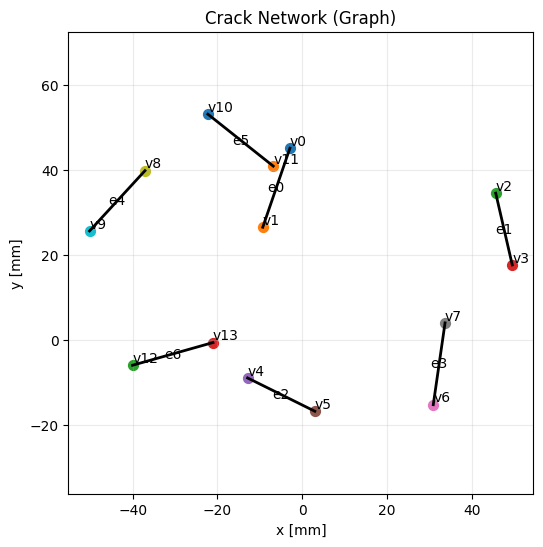

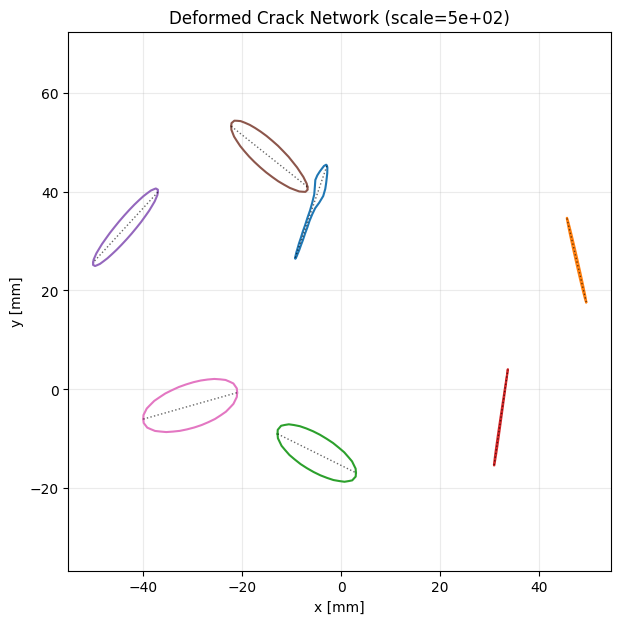

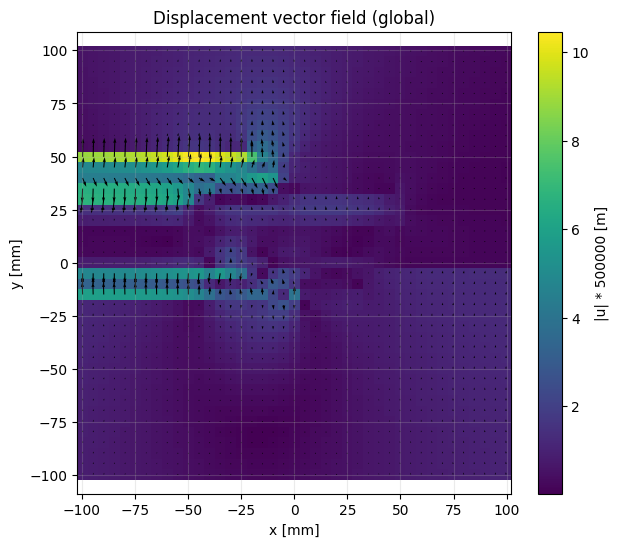

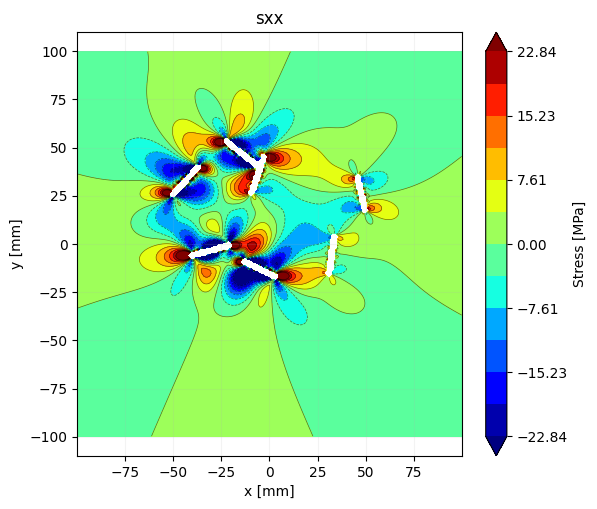

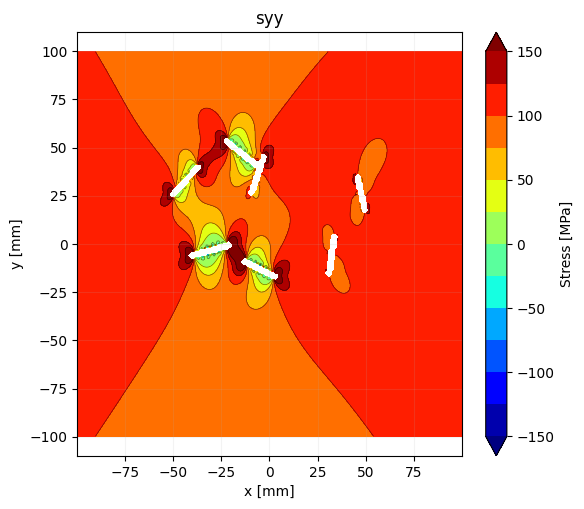

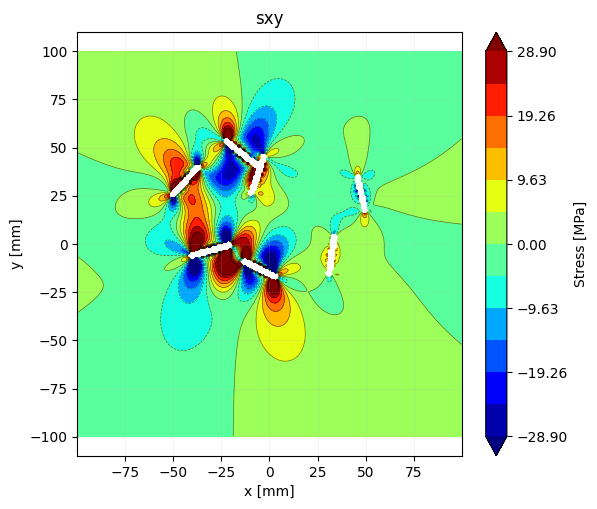

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# --- Ensure repo root on sys.path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)


import utils
utils.reload_all()
from utils import *
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-2")
out_dir.mkdir(parents=True, exist_ok=True)


# Create generator
mm = 1e-3
generator = generator.CrackNetworkGenerator(
    domain_size=(100*mm, 100*mm),
    seed=42  # For reproducibility
)

# Generate network
generator.generate_network(
    n_junctions=0,           # Number of junction vertices
    n_tips=15,                # Number of tip vertices
    edge_length_mean=40*mm,   # Mean edge length
    edge_length_std=5*mm,    # Std dev of edge length
    max_junction_order=3,    # Max junction degree (3-4 typical)
    spatial_distribution='uniform',  # 'uniform', 'clustered', 'grid'
    connection_strategy='nearest_neighbor',  # 'nearest_neighbor', 'delaunay', 'random'
    min_edge_length=5*mm,
    max_edge_length=20*mm
)

# Print statistics
generator.print_statistics()

# Visualize
fig, ax = generator.visualize(
    figsize=(12, 10),
    show_labels=False,
    show_edge_labels=False,
    node_size=10,
    edge_color='blue',
    edge_width=2.0
)
plt.show()

# Export to your format
vertices, connectivity = generator.to_arrays()

print("\n" + "="*60)
print("EXPORTED ARRAYS")
print("="*60)
print("\nvertices =")
print(vertices)
print("\nconnectivity =")
print(connectivity)

# Use with your CrackNetworkV4
net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material=material, network=net, applied=applied)

sol = calc.solve(
    ne_half=5,                   # start here
    representation="cheb_quad",   # keep cheb_quad and cheb_spectral available
    node_distribution="tip_dense"
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# -------------------------
# Network-level plots
# -------------------------
plotter.plot_network_graph()
plotter.plot_deformed_network(scale=5e2, n_pts_per_edge=1000)  # scale in plot title

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e5,       # <--- magnify displacements for visibility
)

# Stress fields (global) with bands/contours
opts = StressPlotOptsV4(
    extent_factor=2,
    n_grid=251,
    add_remote=True,
    vmax_factor=1.5,     # cap at 10x remote component (MPa basis)
    cmap="jet",
    n_bands=12,
    label_contours=False,
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)



CRACK NETWORK STATISTICS

Vertices:
  Total: 24
  Tips (degree 1): 10
  Kinks (degree 2): 14
  Junctions (degree 3+): 0

Edges:
  Total: 19
  Length range: [2.11, 8.71] mm
  Mean length: 5.80 mm
  Std dev: 1.58 mm

Degree distribution:
  Degree 1: 10 vertices
  Degree 2: 14 vertices

Connected components (paths): 5
  Path 1: 3 vertices, 2 edges
  Path 2: 6 vertices, 5 edges
  Path 3: 3 vertices, 2 edges
  Path 4: 9 vertices, 8 edges
  Path 5: 3 vertices, 2 edges


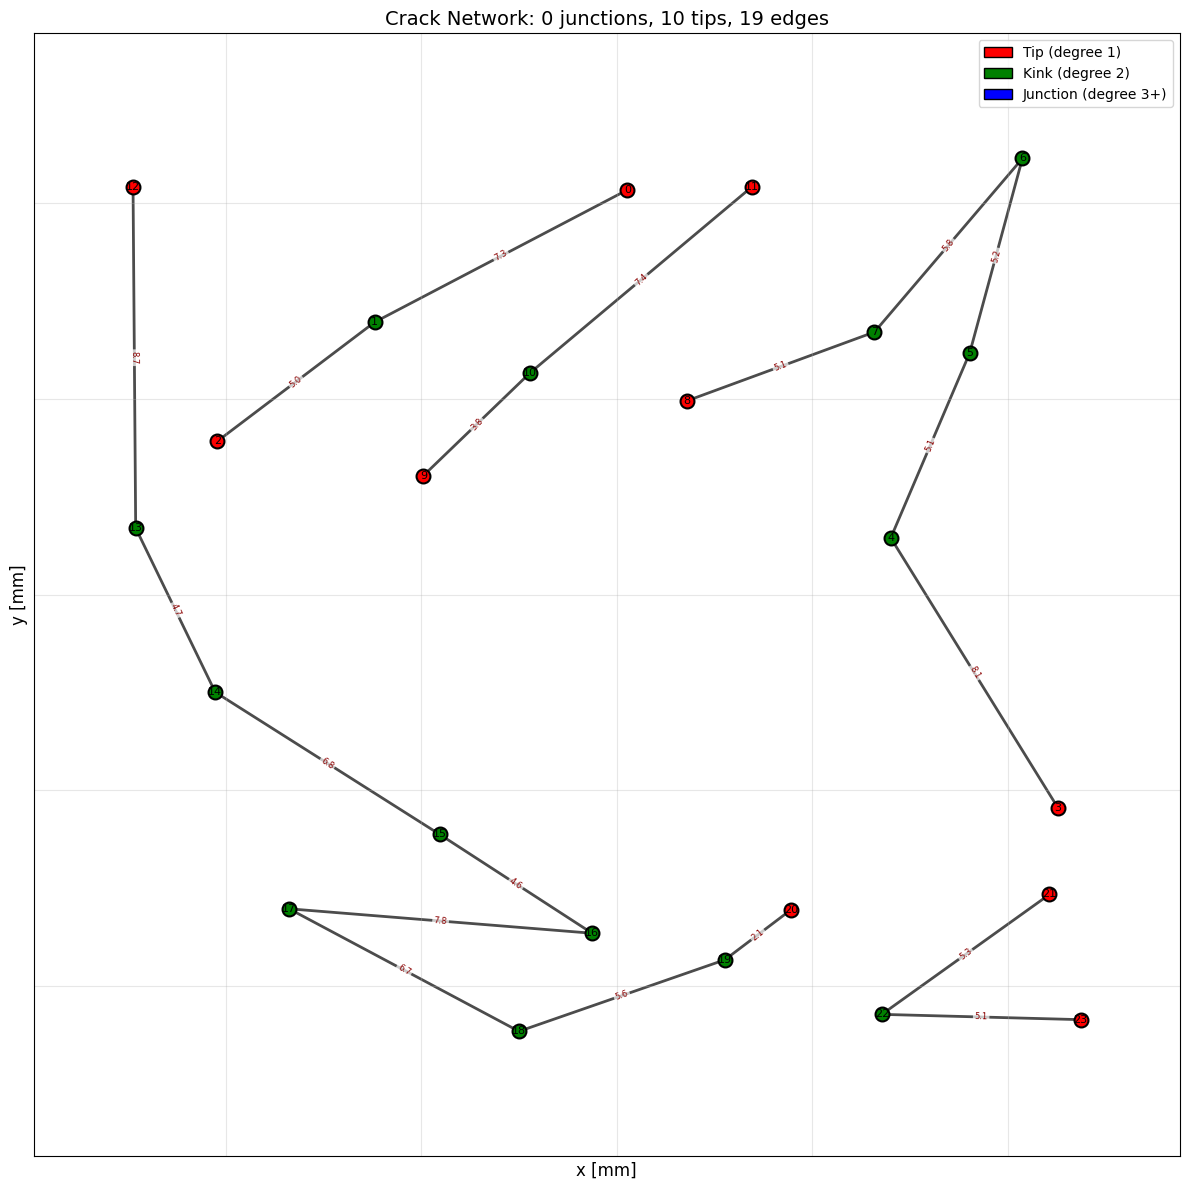

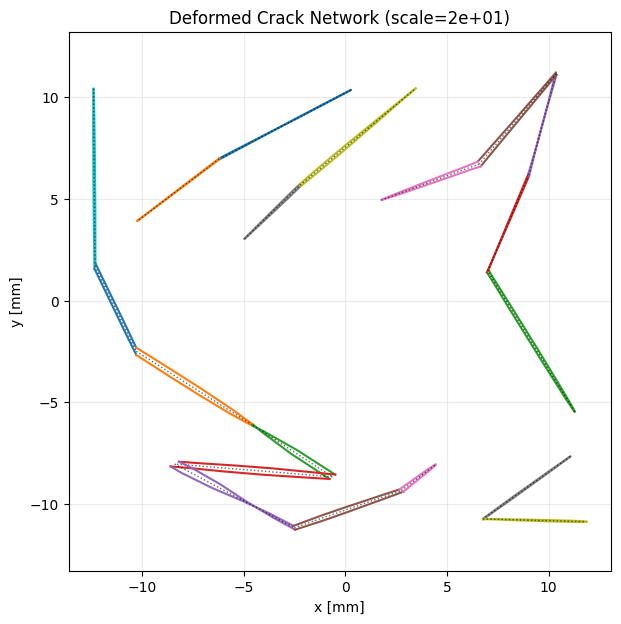

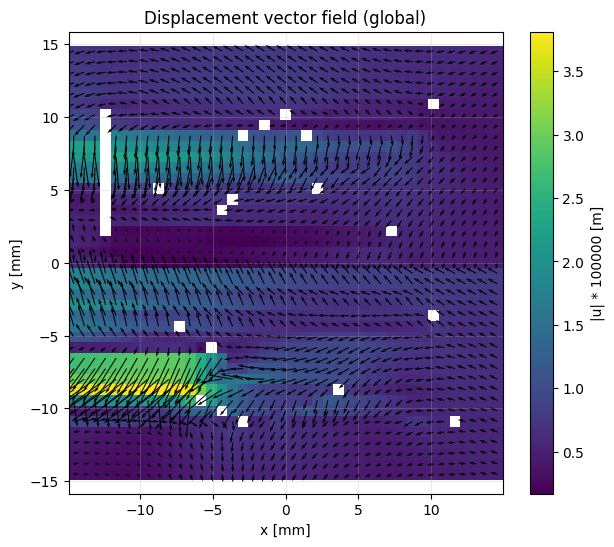

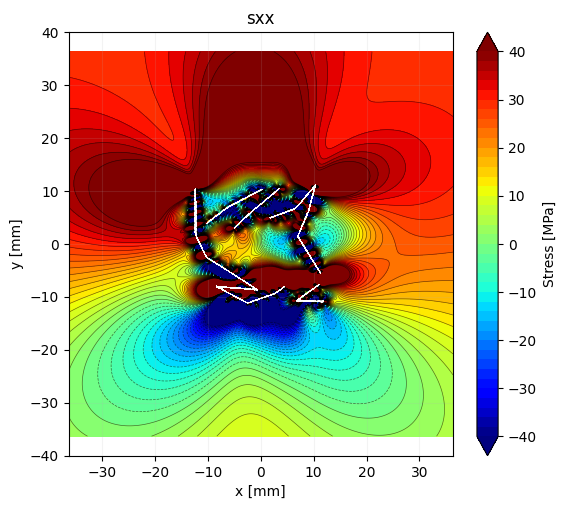

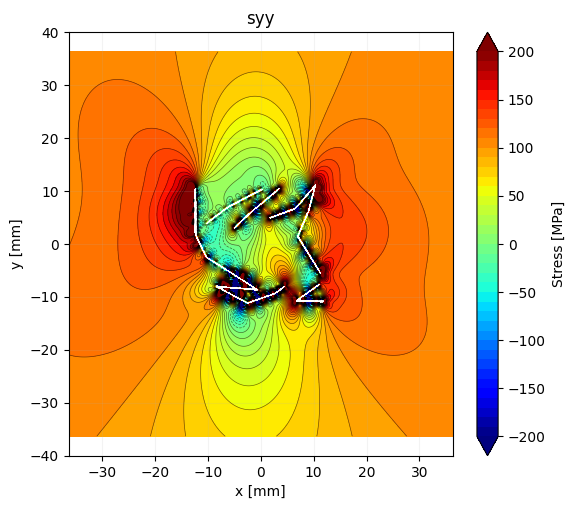

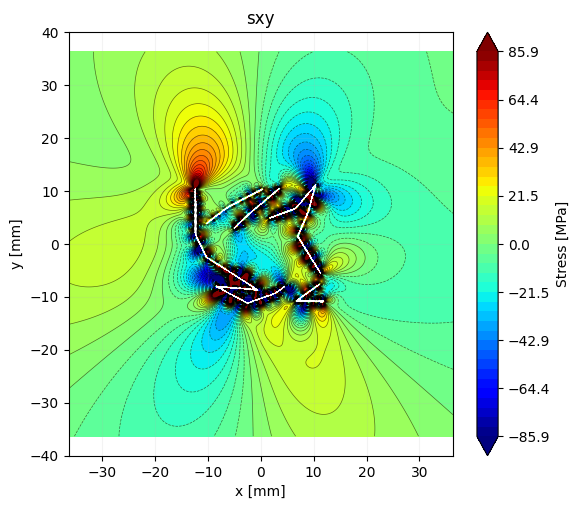

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\parametrized_cracks_2seg


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# --- Ensure repo root on sys.path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils
utils.reload_all()
from utils import *

# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\parametrized_cracks_2seg")
out_dir.mkdir(parents=True, exist_ok=True)

mm=1e-3
# Generate exactly 3 non-intersecting meandering cracks, each with 3 edges
generator = CrackNetworkGenerator(
    domain_size=(25*mm, 25*mm),
    seed=4  # Change seed for different patterns
)

generator.generate_network(
    n_junctions=0,
    n_tips=0,
    
    # Edge properties for meandering
    edge_length_mean=5*mm,
    edge_length_std=2*mm,
    min_edge_length=2*mm,
    max_edge_length=10*mm,
    
    # Exactly 3 cracks, each with 3 segments
    n_crack_paths=5,
    segments_per_path_mean=4,
    segments_per_path_std=2,  # Some variation in segments per path
    
    # Small random angles for meandering
    path_angle_change_mean_deg=0.0,     # No systematic turn
    path_angle_change_std_deg=30.0,     # Small random angles (±30°)
    
    # Non-intersecting
    allow_intersections=False,
    min_edge_distance=1.0*mm,  # Keep cracks separated
    
    spatial_distribution='clustered'
)

# Print statistics
generator.print_statistics()

# Visualize with path coloring to see the 3 separate cracks
fig2, ax2 = generator.visualize(
    figsize=(12, 12),
    node_size=100,
    edge_width=2.0,
    show_labels=True,
    show_edge_labels=True,
    edge_color='black'
)
plt.show()
vertices, connectivity = generator.to_arrays()

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=20e6, sigma_yy=100e6, sigma_xy=0e6)

calc = DCENetworkStaticV4(material, net, applied)

# -------------------------
# Parametrized crack solve (no COD=0 enforced at the interior degree-2 vertex)
# -------------------------
sol = calc.solve(
    ne_half=10,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,   # OK to keep; ignored by the delegated single-crack solve
    n_int=96,
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Deformed crack network
plotter.plot_deformed_network(scale=2e1, n_pts_per_edge=500, 
                              n_theta=10000,show_faces=True)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=1e5,
    mask_cracks=True,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=1000,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
    mask_width_factor=1e-2
)

plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)





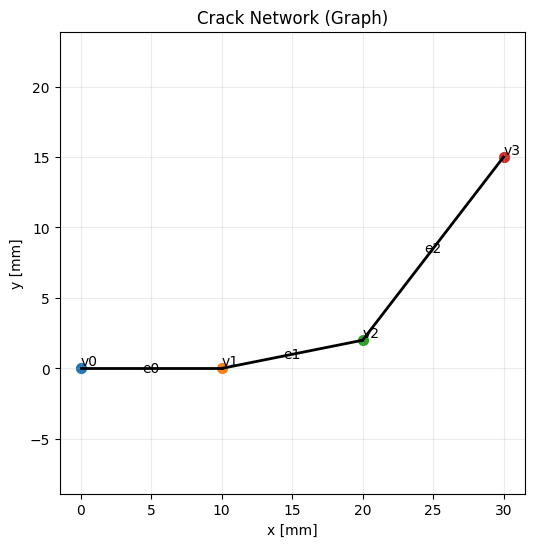

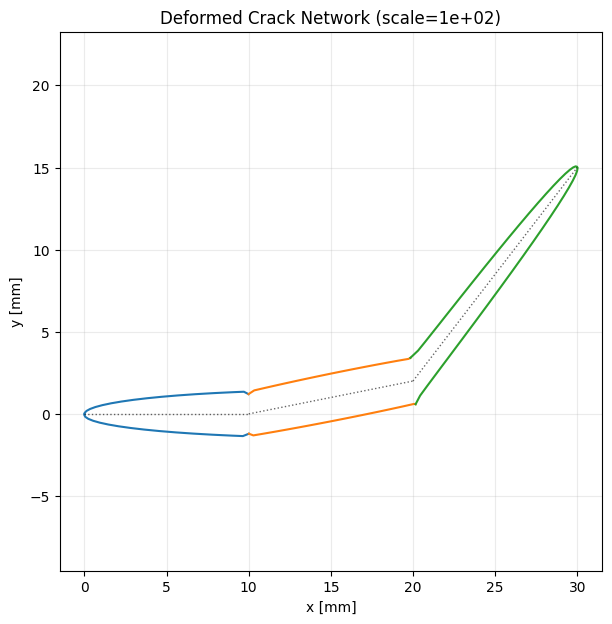

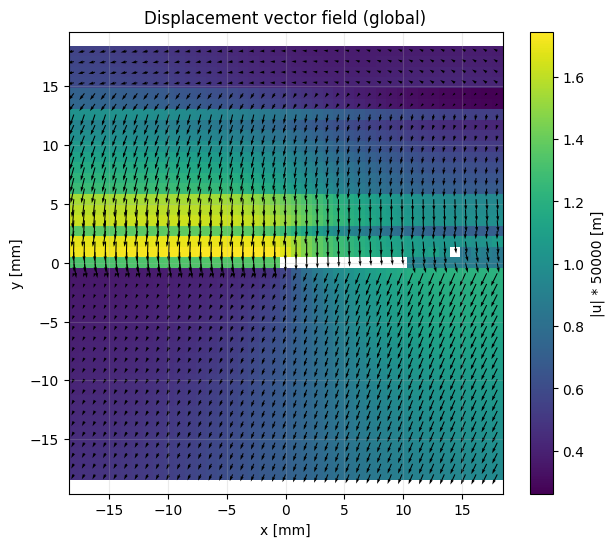

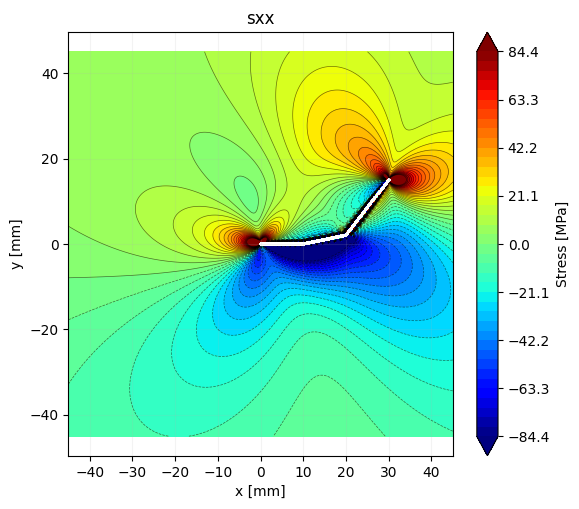

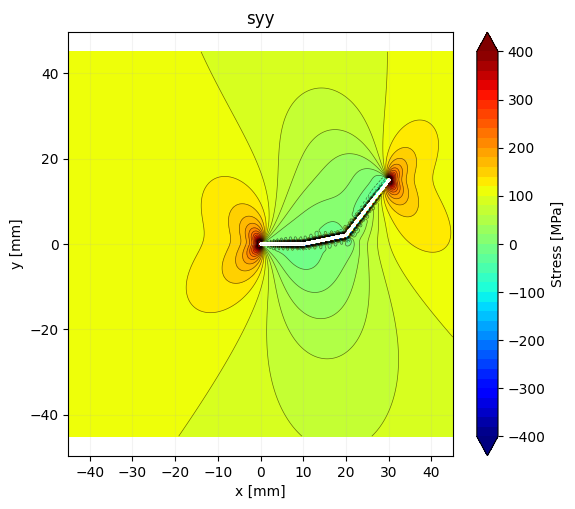

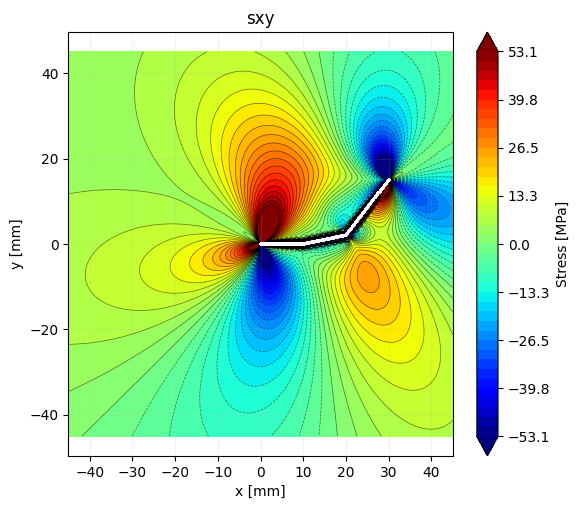

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\kinks_2seg


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# --- Ensure repo root on sys.path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils
utils.reload_all()
from utils import *

# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\kinks_2seg")
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# crack definition (2 segments in a chain: v0--v1--v2)
# units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 (left end)
    [1,  10.0*mm,  0.0*mm],   # v1 (kink / interior vertex, degree 2)
    [2,  20.0*mm,  2*mm],   # v2 (right end)
    [3,  30.0*mm,  15*mm],   # v3 (extra vertex, not used)
], dtype=float)

connectivity = np.array([
    [0, 1],   # e0
    [1, 2],   # e1
    [2, 3]
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0e6)

calc = DCENetworkStaticV4(material, net, applied)

# -------------------------
# Parametrized crack solve (no COD=0 enforced at the interior degree-2 vertex)
# -------------------------
sol = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,   # OK to keep; ignored by the delegated single-crack solve
    n_int=96,
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=1e2, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=True,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    mask_width_factor=1e-4,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=4
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)




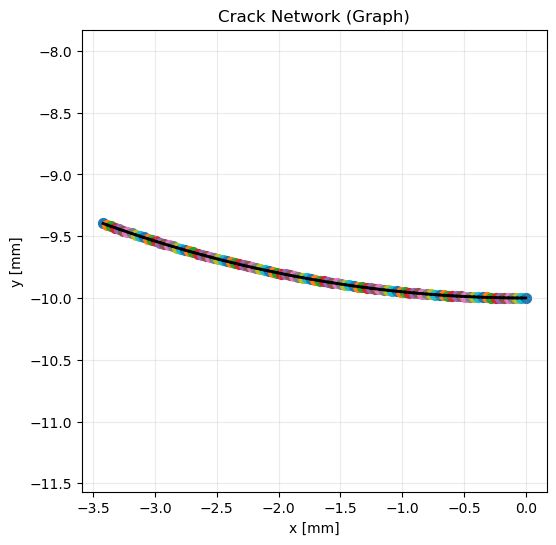

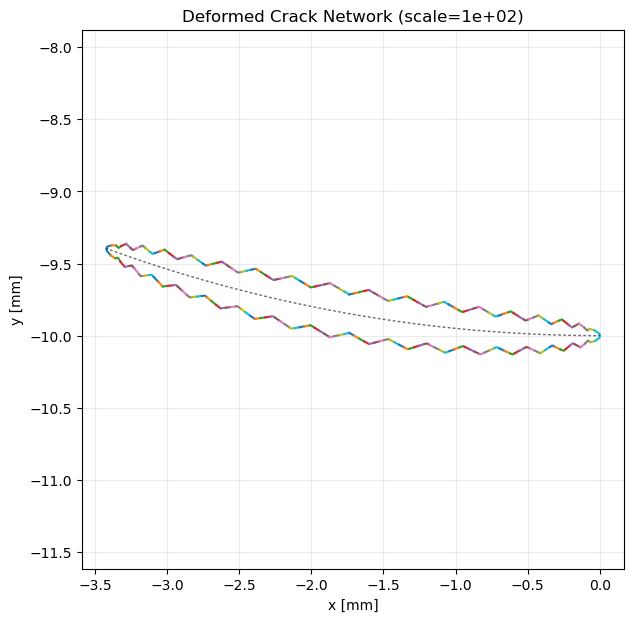

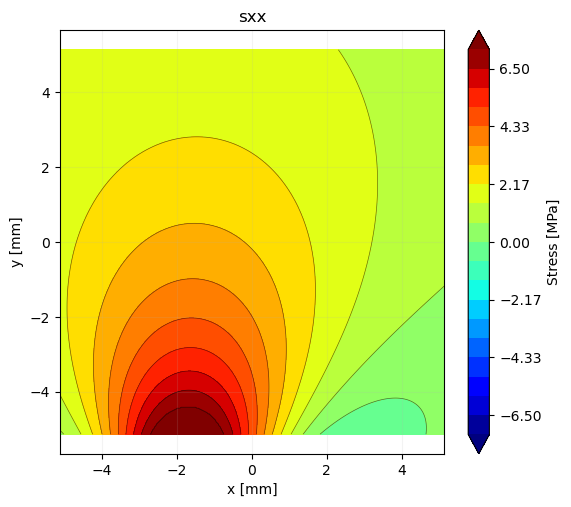

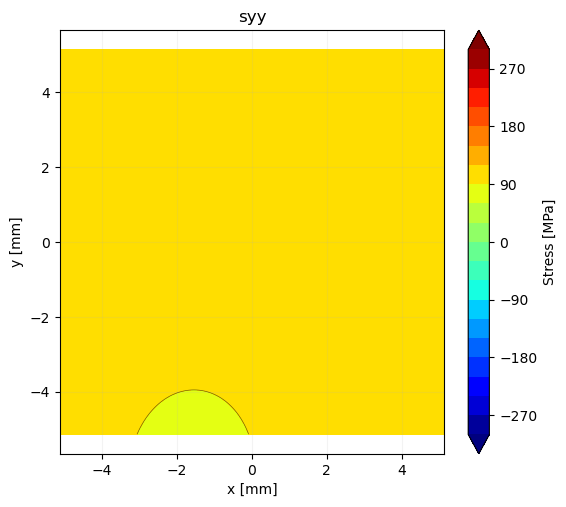

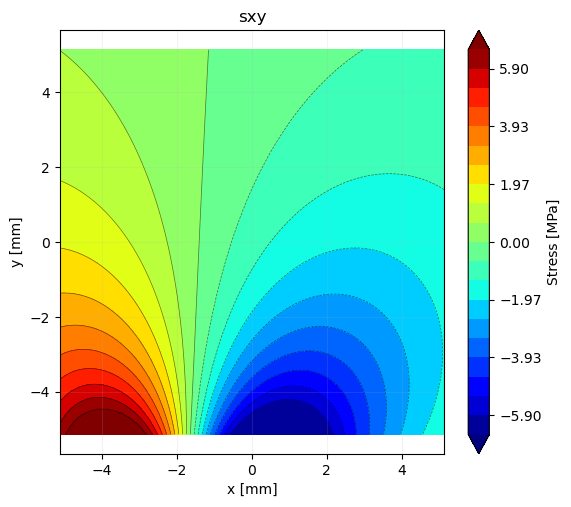

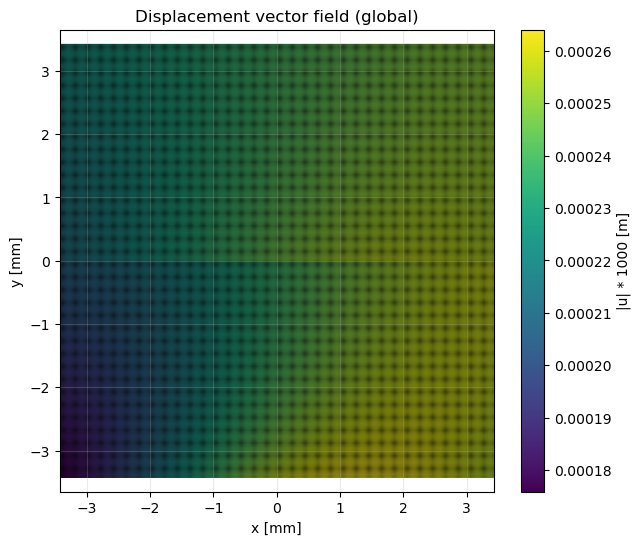

[edge   0 | tip left ] Fit:  KI= 1.172695e+06, KII=-3.132935e+05   |   Jump: KI= 6.805837e+06, KII=-1.818226e+06
[edge  99 | tip right] Fit:  KI= 1.248041e+06, KII=-1.069619e+05   |   Jump: KI= 7.243116e+06, KII=-6.207624e+05

---- Circular-arc crack SIF results ----
rho = 1.000e-02 m, alpha = -10.00 deg, chord c = 3.473e-03 m, sigma = 1.000e+08 Pa

Tip A (arc start):
  Fit : KI=1.172695e+06,  KII=-3.132935e+05   |  FI=1.587724e-01,  FII=-4.241713e-02
  Jump: KI=6.805837e+06, KII=-1.818226e+06  |  FI=9.214493e-01, FII=-2.461715e-01

Tip B (arc end):
  Fit : KI=1.248041e+06,  KII=-1.069619e+05   |  FI=1.689736e-01,  FII=-1.448168e-02
  Jump: KI=7.243116e+06, KII=-6.207624e+05  |  FI=9.806530e-01, FII=-8.404568e-02


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils
utils.reload_all()
from utils import *
from utils.processor_sif import sih_circular_sector_sif_biaxial  # add this

# Output directory
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\arc_crack")
out_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1) Geometry: circular arc polyline
# -----------------------------
def circular_arc_vertices(rho, alpha_deg, n_segments, center=(0.0, 0.0), theta0_deg=0.0):
    alpha = np.deg2rad(alpha_deg)
    theta0 = np.deg2rad(theta0_deg)
    # thetas = np.linspace(theta0 - alpha, theta0 + alpha, n_segments + 1)
    thetas = np.linspace(-2*alpha, 0, n_segments + 1)

    cx, cy = center
    y = cx - rho * np.cos(thetas)
    x = cy - rho * np.sin(thetas)
    return np.column_stack([x, y])

def polyline_connectivity(n_vertices: int):
    return [(i, i + 1) for i in range(n_vertices - 1)]

# -----------------------------
# 2) Problem setup
# -----------------------------
rho       = 10e-3
alpha_deg = -10.0
nseg      = 100
theta0_deg = -alpha_deg

vertices = circular_arc_vertices(rho=rho, alpha_deg=alpha_deg, n_segments=nseg, center=(0, 0), theta0_deg=theta0_deg)
connectivity = polyline_connectivity(len(vertices))

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
sigma = 100e6
applied = AppliedStress(sigma_xx=0, sigma_yy=sigma, sigma_xy=0.0)

dce = DCENetworkStaticV4(material=material, network=net, applied=applied)
sol = dce.solve(
    ne_half=20,
    node_distribution="tip_dense",
    representation="cheb_quad",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_stress=6,
    ridge=0.0,
)


res = DCEResultsNetworkV4(calc=dce, sol=sol)

# -----------------------------
# 3) Plots
# -----------------------------
plt.close("all")
plotter = DCEPlotterV4(results=res, out_dir=None)

plotter.plot_network_graph(units="mm", annotate=False)

plotter.plot_deformed_network(
    scale=1e2,
    n_pts_per_edge=80,
    units="mm",
    use_panel_midpoints=True,
    cod_smooth_window=0,
    csd_smooth_window=0,
)

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    clip_percentiles=(1.0, 99.0),
    vmax_factor=3.0,
)
plotter.plot_stress_components_global(opts=opts, components=("sxx", "syy", "sxy"))

plotter.plot_displacement_vector_field(
    extent_factor=2,
    n_grid=400,
    scale=1.0,
    disp_scale=1e3,
    mask_cracks=True,
)

plt.show()

# -----------------------------
# 4) SIF extraction (fit + near-tip jump)
# -----------------------------
def edge_half_length_from_network(network: CrackNetworkV4, edge_index: int) -> float:
    e = network.edges[int(edge_index)]
    v0 = network.V(e.v0); v1 = network.V(e.v1)
    L = float(np.hypot(v1.x - v0.x, v1.y - v0.y))
    return 0.5 * L

def estimate_KI_KII_from_jumps_near_tip_local(x, COD, CSD, a, Eprime, side="right", frac_window=0.08):
    """
    Local wrapper: returns both KI and KII using the existing scalar estimator.
      KI  <- COD
      KII <- CSD
    """
    KI_jump  = estimate_K_from_jump_near_tip(x, COD, a, Eprime, side=side, frac_window=frac_window)
    KII_jump = estimate_K_from_jump_near_tip(x, CSD, a, Eprime, side=side, frac_window=frac_window)
    return KI_jump, KII_jump

mu = material.mu
kappa = material.kappa

edge_left  = 0
edge_right = len(net.edges) - 1

pA = vertices[0]
pB = vertices[-1]
c = float(np.hypot(*(pB - pA)))

def compute_tip_sif_for_edge(edge_index: int, which_tip: str, *, frac_window=0.08, verbose=True):
    a = edge_half_length_from_network(net, edge_index)

    x, COD, CSD = res.reconstruct_cod_csd_parametrized(
        edge_index=edge_index,
        n_pts=6000,
        enforce_global_tip_zero=True
    )

    # Fit-based
    KI_fit, KII_fit, meta_fit = sif_from_cod_fit(
        x, COD, CSD, a=a, mu=mu, kappa=kappa, tip=which_tip, window="auto"
    )

    # E'
    E = material.E
    nu = material.nu
    Eprime = E if material.plane_stress else E / (1.0 - nu**2)

    # Use same 'left'/'right' convention
    side = which_tip
    KI_jump, KII_jump = estimate_KI_KII_from_jumps_near_tip_local(
        x, COD, CSD, a, Eprime, side=side, frac_window=frac_window
    )

    if verbose:
        print(f"[edge {edge_index:3d} | tip {which_tip:5s}] "
              f"Fit:  KI={KI_fit: .6e}, KII={KII_fit: .6e}   |   "
              f"Jump: KI={KI_jump: .6e}, KII={KII_jump: .6e}")

    return KI_fit, KII_fit, meta_fit, KI_jump, KII_jump

KI_A, KII_A, metaA, KI_Aj, KII_Aj = compute_tip_sif_for_edge(edge_left,  which_tip="left")
KI_B, KII_B, metaB, KI_Bj, KII_Bj = compute_tip_sif_for_edge(edge_right, which_tip="right")

Fden = sigma * np.sqrt(np.pi * (c / 2.0))

FI_A,  FII_A  = KI_A  / Fden, KII_A  / Fden
FI_B,  FII_B  = KI_B  / Fden, KII_B  / Fden
FI_Aj, FII_Aj = KI_Aj / Fden, KII_Aj / Fden
FI_Bj, FII_Bj = KI_Bj / Fden, KII_Bj / Fden

print("\n---- Circular-arc crack SIF results ----")
print(f"rho = {rho:.3e} m, alpha = {alpha_deg:.2f} deg, chord c = {c:.3e} m, sigma = {sigma:.3e} Pa")

print("\nTip A (arc start):")
print(f"  Fit : KI={KI_A:.6e},  KII={KII_A:.6e}   |  FI={FI_A:.6e},  FII={FII_A:.6e}")
print(f"  Jump: KI={KI_Aj:.6e}, KII={KII_Aj:.6e}  |  FI={FI_Aj:.6e}, FII={FII_Aj:.6e}")

print("\nTip B (arc end):")
print(f"  Fit : KI={KI_B:.6e},  KII={KII_B:.6e}   |  FI={FI_B:.6e},  FII={FII_B:.6e}")
print(f"  Jump: KI={KI_Bj:.6e}, KII={KII_Bj:.6e}  |  FI={FI_Bj:.6e}, FII={FII_Bj:.6e}")




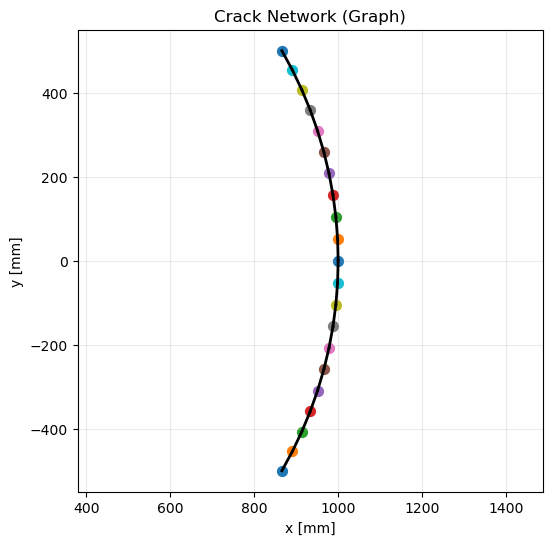

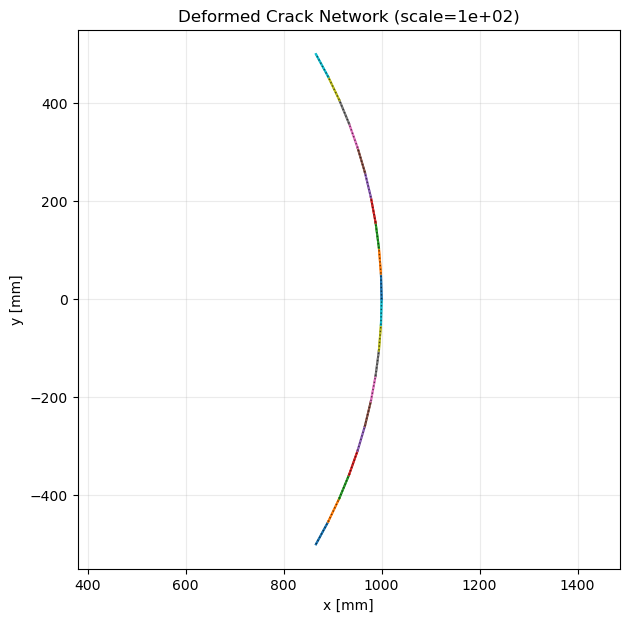

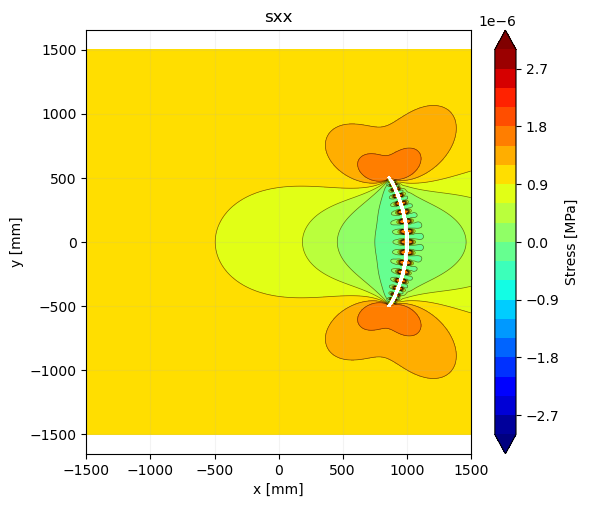

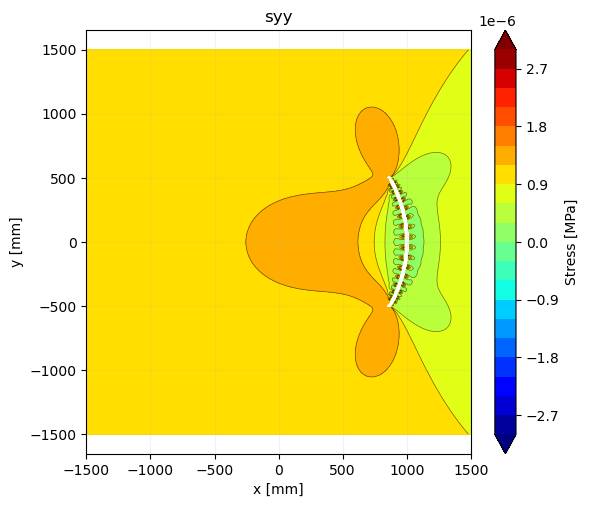

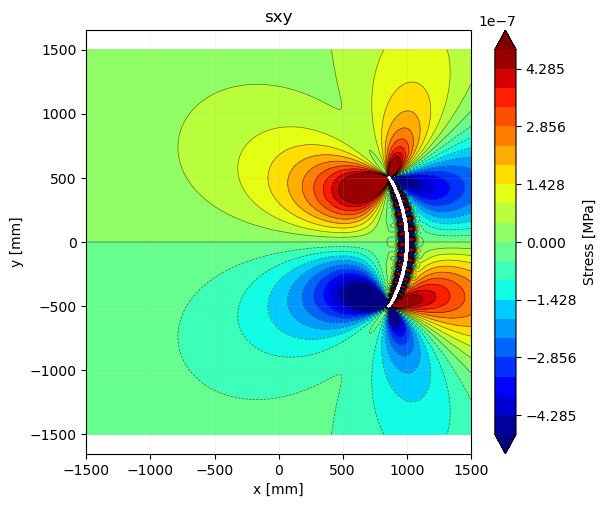

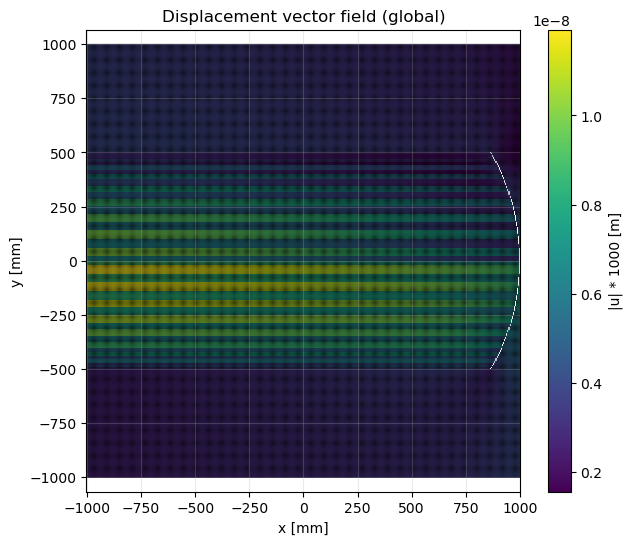

[edge   0 | tip left ] Fit:  KI= 5.188940e-01, KII=-9.192980e-03   |   Jump: KI= 2.789841e+00, KII=-5.071134e-02
[edge  19 | tip right] Fit:  KI= 5.188940e-01, KII= 9.192980e-03   |   Jump: KI= 2.789841e+00, KII= 5.071134e-02

---- Circular-arc crack SIF results ----
rho = 1.000e+00 m, alpha = 30.00 deg, chord c = 1.000e+00 m, sigma = 1.000e+00 Pa

Tip A (arc start):
  Fit : KI=5.188940e-07,  KII=-9.192980e-09   |  FI=4.140175e-01,  FII=-7.334937e-03
  Jump: KI=2.789841e-06, KII=-5.071134e-08  |  FI=2.225971e+00, FII=-4.046180e-02

Tip B (arc end):
  Fit : KI=5.188940e-07,  KII=9.192980e-09   |  FI=4.140175e-01,  FII=7.334937e-03
  Jump: KI=2.789841e-06, KII=5.071134e-08  |  FI=2.225971e+00, FII=4.046180e-02

---- Analytical SIFs for circular-sector crack in biaxial loading ----
Chord length c = 0.8660254037844386
Tip +alpha: KI = 6.401319894843074e-07  KII = 1.7152284963164803e-07
Tip -alpha: KI = 6.401319894843074e-07  KII = 1.7152284963164803e-07


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils
utils.reload_all()
from utils import *
from utils.processor_sif import sih_circular_sector_sif_biaxial  # add this

# Output directory
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\arc_crack")
out_dir.mkdir(parents=True, exist_ok=True)


# import inspect
# import utils
# import VariationalCracks.utils.solver_parametrized as sp
# from utils.solver import DCENetworkStaticV4


# -----------------------------
# 1) Geometry: circular arc polyline
# -----------------------------
def circular_arc_vertices(rho, alpha_deg, n_segments, center=(0.0, 0.0), theta0_deg=0.0):
    alpha = np.deg2rad(alpha_deg)
    theta0 = np.deg2rad(theta0_deg)
    # thetas = np.linspace(theta0 - alpha, theta0 + alpha, n_segments + 1)
    thetas = np.linspace(-alpha, alpha, n_segments + 1)

    cx, cy = center
    x = cx + rho * np.cos(thetas)
    y = cy + rho * np.sin(thetas)
    return np.column_stack([x, y])

def polyline_connectivity(n_vertices: int):
    return [(i, i + 1) for i in range(n_vertices - 1)]

# -----------------------------
# 2) Problem setup
# -----------------------------
rho       = 1
alpha_deg = 30.0
nseg      = 20
theta0_deg = 0.0

vertices = circular_arc_vertices(rho=rho, alpha_deg=alpha_deg, n_segments=nseg, center=(0, 0), theta0_deg=theta0_deg)
connectivity = polyline_connectivity(len(vertices))

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
sigma = 1
applied = AppliedStress(sigma_xx=sigma, sigma_yy=sigma, sigma_xy=0.0)

dce = DCENetworkStaticV4(material=material, network=net, applied=applied)
sol = dce.solve(
    ne_half=20,
    node_distribution="tip_dense",
    representation="cheb_quad",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_stress=6,
    ridge=0.0,
)


res = DCEResultsNetworkV4(calc=dce, sol=sol)


# -----------------------------
# 3) Plots
# -----------------------------
plt.close("all")
plotter = DCEPlotterV4(results=res, out_dir=None)

plotter.plot_network_graph(units="mm", annotate=False)

plotter.plot_deformed_network(
    scale=1e2,
    n_pts_per_edge=80,
    units="mm",
    use_panel_midpoints=True,
    cod_smooth_window=0,
    csd_smooth_window=0,
)

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    clip_percentiles=(1.0, 99.0),
    vmax_factor=3.0,
)
plotter.plot_stress_components_global(opts=opts, components=("sxx", "syy", "sxy"))

plotter.plot_displacement_vector_field(
    extent_factor=2,
    n_grid=400,
    scale=1.0,
    disp_scale=1e3,
    mask_cracks=True,
)

plt.show()

# -----------------------------
# 4) SIF extraction (fit + near-tip jump)
# -----------------------------
def edge_half_length_from_network(network: CrackNetworkV4, edge_index: int) -> float:
    e = network.edges[int(edge_index)]
    v0 = network.V(e.v0); v1 = network.V(e.v1)
    L = float(np.hypot(v1.x - v0.x, v1.y - v0.y))
    return 0.5 * L

def estimate_KI_KII_from_jumps_near_tip_local(x, COD, CSD, a, Eprime, side="right", frac_window=0.08):
    """
    Local wrapper: returns both KI and KII using the existing scalar estimator.
      KI  <- COD
      KII <- CSD
    """
    KI_jump  = estimate_K_from_jump_near_tip(x, COD, a, Eprime, side=side, frac_window=frac_window)
    KII_jump = estimate_K_from_jump_near_tip(x, CSD, a, Eprime, side=side, frac_window=frac_window)
    return KI_jump, KII_jump

mu = material.mu
kappa = material.kappa

edge_left  = 0
edge_right = len(net.edges) - 1

pA = vertices[0]
pB = vertices[-1]
c = float(np.hypot(*(pB - pA)))

def compute_tip_sif_for_edge(edge_index: int, which_tip: str, *, frac_window=0.08, verbose=True):
    a = edge_half_length_from_network(net, edge_index)

    x, COD, CSD = res.reconstruct_cod_csd_parametrized(
        edge_index=edge_index,
        n_pts=6000,
        enforce_global_tip_zero=True
    )

    # Fit-based
    KI_fit, KII_fit, meta_fit = sif_from_cod_fit(
        x, COD, CSD, a=a, mu=mu, kappa=kappa, tip=which_tip, window="auto"
    )

    # E'
    E = material.E
    nu = material.nu
    Eprime = E if material.plane_stress else E / (1.0 - nu**2)

    # Use same 'left'/'right' convention
    side = which_tip
    KI_jump, KII_jump = estimate_KI_KII_from_jumps_near_tip_local(
        x, COD, CSD, a, Eprime, side=side, frac_window=frac_window
    )

    if verbose:
        print(f"[edge {edge_index:3d} | tip {which_tip:5s}] "
              f"Fit:  KI={KI_fit: .6e}, KII={KII_fit: .6e}   |   "
              f"Jump: KI={KI_jump: .6e}, KII={KII_jump: .6e}")

    return KI_fit, KII_fit, meta_fit, KI_jump, KII_jump

KI_A, KII_A, metaA, KI_Aj, KII_Aj = compute_tip_sif_for_edge(edge_left,  which_tip="left")
KI_B, KII_B, metaB, KI_Bj, KII_Bj = compute_tip_sif_for_edge(edge_right, which_tip="right")

Fden = sigma * np.sqrt(np.pi * (c / 2.0))

FI_A,  FII_A  = KI_A  / Fden, KII_A  / Fden
FI_B,  FII_B  = KI_B  / Fden, KII_B  / Fden
FI_Aj, FII_Aj = KI_Aj / Fden, KII_Aj / Fden
FI_Bj, FII_Bj = KI_Bj / Fden, KII_Bj / Fden

print("\n---- Circular-arc crack SIF results ----")
print(f"rho = {rho:.3e} m, alpha = {alpha_deg:.2f} deg, chord c = {c:.3e} m, sigma = {sigma:.3e} Pa")

print("\nTip A (arc start):")
print(f"  Fit : KI={KI_A/1e6:.6e},  KII={KII_A/1e6:.6e}   |  FI={FI_A:.6e},  FII={FII_A:.6e}")
print(f"  Jump: KI={KI_Aj/1e6:.6e}, KII={KII_Aj/1e6:.6e}  |  FI={FI_Aj:.6e}, FII={FII_Aj:.6e}")

print("\nTip B (arc end):")
print(f"  Fit : KI={KI_B/1e6:.6e},  KII={KII_B/1e6:.6e}   |  FI={FI_B:.6e},  FII={FII_B:.6e}")
print(f"  Jump: KI={KI_Bj/1e6:.6e}, KII={KII_Bj/1e6:.6e}  |  FI={FI_Bj:.6e}, FII={FII_Bj:.6e}")


alpha =np.pi / 6  # 30 degrees in radians
print("\n---- Analytical SIFs for circular-sector crack in biaxial loading ----")

# Tip at +alpha
KI_A, KII_A, c = sih_circular_sector_sif_biaxial(alpha, sigma, rho=rho, tip=+1)

# Tip at -alpha (KII changes sign)
KI_B, KII_B, c = sih_circular_sector_sif_biaxial(alpha, sigma, rho=rho, tip=-1)

print("Chord length c =", c)
print("Tip +alpha: KI =", KI_A/1e6, " KII =", KII_A/1e6)
print("Tip -alpha: KI =", KI_B/1e6, " KII =", KII_B/1e6)